# SVD

Example from [data-driven book](https://www.databookuw.com/).

A matrix $A \in \mathbb{R}^{m \times n}$ has singular value decomposition:

$A = U \Sigma V^T$

| Matrix | Shape | Characteristics |
|--------|-------|------------|
| $U$ | $m \times m$ | orthogonal, columns = left singular vectors |
| $\Sigma$ | $m \times n$ | diagonal, $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$ |
| $V^T$ | $n \times n$ | orthogonal, rows = right singular vectors |

## Eckart-Young theorem 

Best rank-$r$ approximation of the original $A$ in Frobenius norm:

$\hat{A}_r = U_r \Sigma_r V_r^T, \quad \|A - \hat{A}_r\|_F = \sqrt{\sum_{i=r+1}^{\min(m,n)} \sigma_i^2}$

Only the $r$ most dominant singular values/vectors are kept. The rest is discarded.

### Storage

- $A$: $mn$ entries
- $\hat{A}_r$ factors ($U_r, \Sigma_r, V_r^T$): $r(m + n + 1)$ entries

### Relative error 

$\|A - \hat{A}_r\|_F / \|A\|_F = \sqrt{1 - \sum_{i=1}^r \sigma_i^2 / \sum_{i=1}^{\min(m,n)} \sigma_i^2}$

In [1]:
import torch
import matplotlib.pyplot as plt
from skimage import data as skdata

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "gray"

## Image matrix SVD

Grayscale image = real matrix with pixel intensity in $[0, 1]$. SVD gives optimal low-rank compression.

shape: 512 x 512
rank:  512


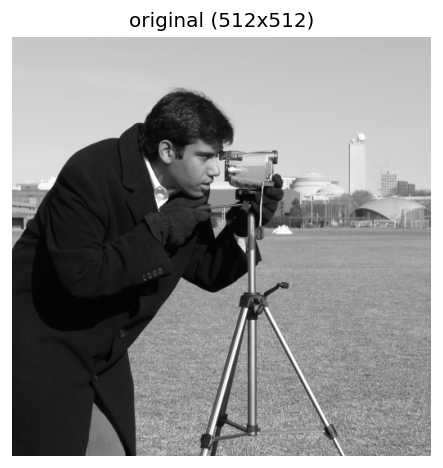

In [2]:
img = torch.tensor(skdata.camera(), dtype=torch.float64) / 255.0
m, n = img.shape
print(f"shape: {m} x {n}")
print(f"rank:  {torch.linalg.matrix_rank(img).item()}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img, vmin=0, vmax=1)
ax.set_title(f"original ({m}x{n})")
ax.axis("off")
plt.tight_layout()
plt.show()

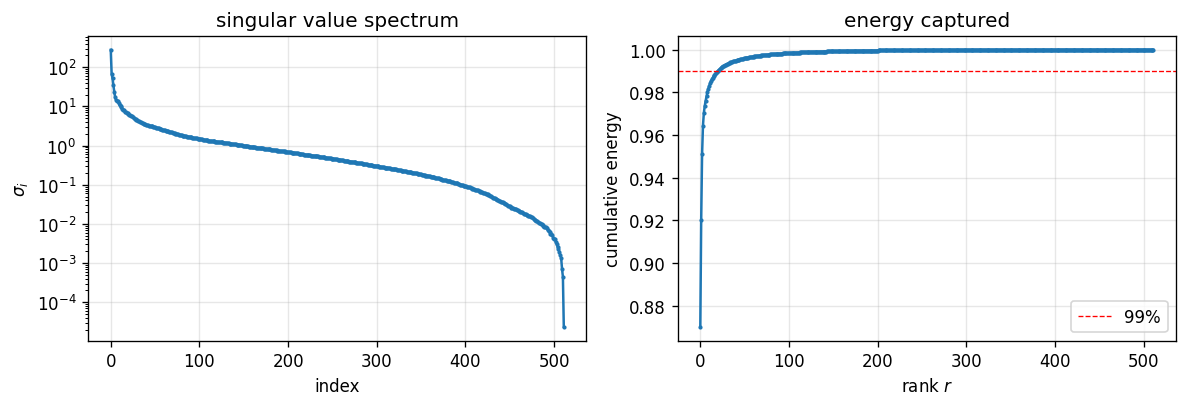

In [3]:
U, S, Vt = torch.linalg.svd(img, full_matrices=False)
total_energy = (S**2).sum()
cumulative_energy = torch.cumsum(S**2, dim=0) / total_energy

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# singular value spectrum
axes[0].semilogy(S.numpy(), ".-", markersize=3)
axes[0].set_xlabel("index")
axes[0].set_ylabel("$\\sigma_i$")
axes[0].set_title("singular value spectrum")
axes[0].grid(True, alpha=0.3)

# cumulative energy
axes[1].plot(cumulative_energy.numpy(), ".-", markersize=3)
axes[1].axhline(0.99, color="r", ls="--", lw=0.8, label="99%")
axes[1].set_xlabel("rank $r$")
axes[1].set_ylabel("cumulative energy")
axes[1].set_title("energy captured")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Truncated reconstruction

Keep only the first $r$ singular values/vectors. Trade accuracy for storage.

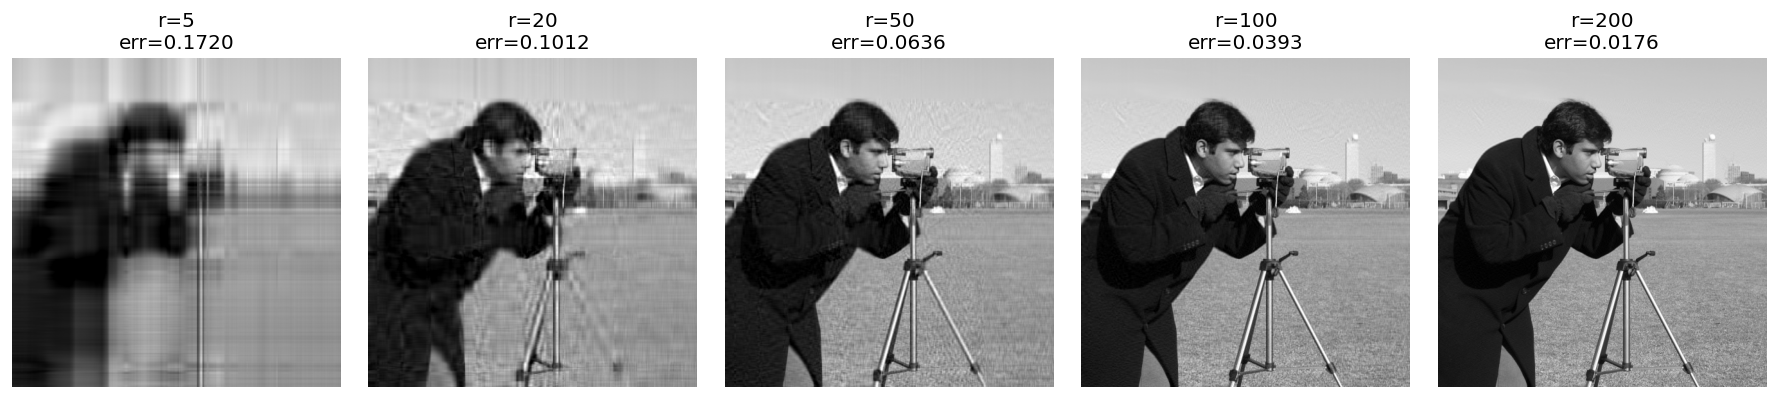

In [4]:
ranks = [5, 20, 50, 100, 200]
norm_A = torch.linalg.norm(img, "fro")

fig, axes = plt.subplots(1, len(ranks), figsize=(3 * len(ranks), 3.2))

# rank-r reconstruction
for ax, r in zip(axes, ranks):
    A_r = U[:, :r] @ torch.diag(S[:r]) @ Vt[:r, :]
    rel_err = torch.linalg.norm(img - A_r, "fro") / norm_A
    ax.imshow(A_r.clamp(0, 1), vmin=0, vmax=1)
    ax.set_title(f"r={r}\nerr={rel_err:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
full_storage = m * n
print(f"{'rank':>6} {'storage':>10} {'ratio':>8} {'rel_err':>10} {'energy':>10}")
print("-" * 50)
for r in ranks:
    trunc_storage = r * (m + n + 1)
    ratio = full_storage / trunc_storage
    rel_err = torch.sqrt(1 - cumulative_energy[r - 1]).item()
    energy = cumulative_energy[r - 1].item()
    print(f"{r:>6} {trunc_storage:>10} {ratio:>8.1f}x {rel_err:>10.6f} {energy:>10.6f}")

  rank    storage    ratio    rel_err     energy
--------------------------------------------------
     5       5125     51.2x   0.172014   0.970411
    20      20500     12.8x   0.101208   0.989757
    50      51250      5.1x   0.063565   0.995959
   100     102500      2.6x   0.039329   0.998453
   200     205000      1.3x   0.017644   0.999689


## Spatial modes and time dynamics

If rows = spatial points and columns = time snapshots, SVD separates space from time.

- $U$ columns = spatial modes (coherent structures in space)
- $\sigma_i$ = mode importance
- $V^T$ rows = time dynamics (how each mode evolves)

Vortex shedding behind a cylinder, from [this](https://github.com/dynamicslab/databook_python).

shape: 89351 spatial points x 151 snapshots


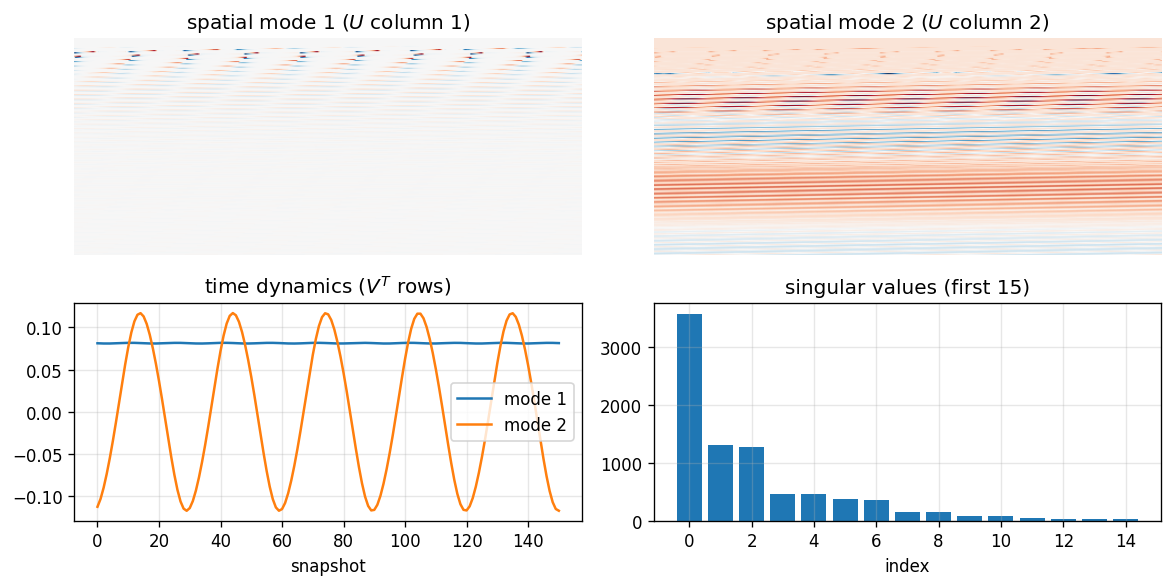

In [6]:
from pathlib import Path
from urllib.request import urlretrieve
from scipy.io import loadmat

# download
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
mat_path = data_dir / "VORTALL.mat"
if not mat_path.exists():
    urlretrieve(
        "https://raw.githubusercontent.com/dynamicslab/databook_python/master/DATA/VORTALL.mat",
        mat_path,
    )

vort = torch.tensor(loadmat(mat_path)["VORTALL"], dtype=torch.float64)  # (nx*ny, nt)
print(f"shape: {vort.shape[0]} spatial points x {vort.shape[1]} snapshots")

U3, S3, Vt3 = torch.linalg.svd(vort, full_matrices=False)

fig, axes = plt.subplots(2, 2, figsize=(10, 5))

# spatial modes (U columns), reshaped to 2D
nx, ny = 199, 449
for i, ax in enumerate(axes[0]):
    mode = U3[:, i].reshape(nx, ny).numpy()
    ax.imshow(mode, aspect="auto", cmap="RdBu_r")
    ax.set_title(f"spatial mode {i + 1} ($U$ column {i + 1})")
    ax.axis("off")

# time dynamics (V rows)
axes[1, 0].plot(Vt3[0, :].numpy(), label="mode 1")
axes[1, 0].plot(Vt3[1, :].numpy(), label="mode 2")
axes[1, 0].set_title("time dynamics ($V^T$ rows)")
axes[1, 0].set_xlabel("snapshot")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# singular values
axes[1, 1].bar(range(15), S3[:15].numpy())
axes[1, 1].set_title("singular values (first 15)")
axes[1, 1].set_xlabel("index")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()